In [84]:
import numpy as np 
def calculate_bact_growth_exp(od, runtime_hours): 
    """ Calculate growth rate from OD measurements. 
    
    Note: this function assumes no dilutions.
    """

    log_od = np.log(od) 
    log_od_diff = log_od - log_od[0]
    growth_rate = log_od_diff / runtime_hours
    return growth_rate 

def calculate_bact_growth_steady(total_inc_dilution, run_time_hours, inc_vol): 
    """ Calculate growth rate from medium consumption.
    
    Note: this function assumes constant od. 
    """
    
    dil_per_hour = total_inc_dilution / run_time_hours
    gr_per_hour = dil_per_hour / inc_vol
    return gr_per_hour


def calculate_bact_growth2(od, total_inc_bursts, burst_dilution, runtime_hours): 
    # Calculate dilution per interval, measured in inc. volumes
    inc_dil_per_interval = (total_inc_bursts[1:] - total_inc_bursts[:-1]) * np.log(burst_dilution)
    dt = runtime_hours[1:] - runtime_hours[:-1]
    log_od = np.log(od)
    log_od_diff = log_od[1:] - log_od[:-1]
    growth_rate = (log_od_diff - inc_dil_per_interval) / dt
    return runtime_hours[1:], growth_rate


In [28]:
import pandas as pd 
import seaborn as sns 

BURST_SIZE_ML = 0.3894
INC_VOL_ML = 38
TOTAL_VOL_ML = 350 

state = pd.read_csv('../experiments/20240512_charlie_state.csv')
state['inc_dilution_ml'] = state['inc_dilution'] * BURST_SIZE_ML
total_num_bursts = state['inc_dilution'].max()
state['inc_dilution_ml2'] = state['inc_dilution'] * TOTAL_VOL_ML / total_num_bursts
state['runtime_h'] = (state['timestamp'] - state.loc[0, 'timestamp']) / 3600
state['growth_rate'] = state.apply(lambda x: calculate_bact_growth_steady(x['inc_dilution_ml'], x['runtime_h'], INC_VOL_ML), axis=1)
state['growth_rate2'] = state.apply(lambda x: calculate_bact_growth_steady(x['inc_dilution_ml2'], x['runtime_h'], INC_VOL_ML), axis=1)


/var/folders/5b/cl1vpvwx7z12hpb0ntpgryk40000gp/T/ipykernel_34747/1524616290.py:2: RuntimeWarning: invalid value encountered in scalar divide
  dil_per_hour = total_inc_dilution / run_time_hours
/var/folders/5b/cl1vpvwx7z12hpb0ntpgryk40000gp/T/ipykernel_34747/1524616290.py:2: RuntimeWarning: invalid value encountered in scalar divide
  dil_per_hour = total_inc_dilution / run_time_hours


<Axes: xlabel='timestamp', ylabel='inc_temp'>

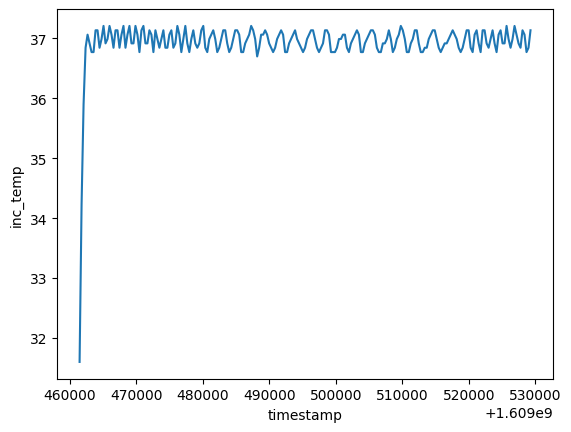

In [29]:
sns.lineplot(state, x='timestamp', y='inc_temp')

<Axes: xlabel='runtime_h', ylabel='inc_od'>

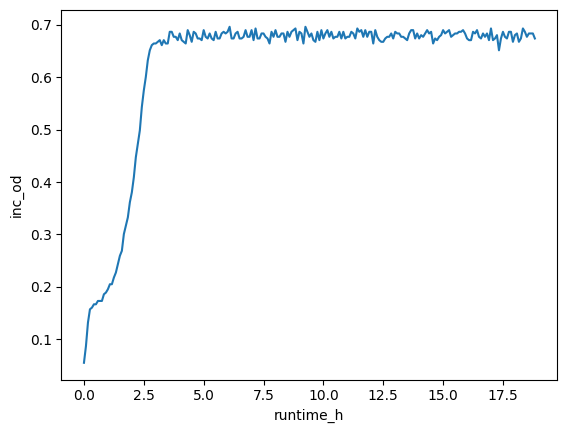

In [30]:
sns.lineplot(state, x='runtime_h', y='inc_od')

<Axes: xlabel='runtime_h', ylabel='inc_dilution_ml'>

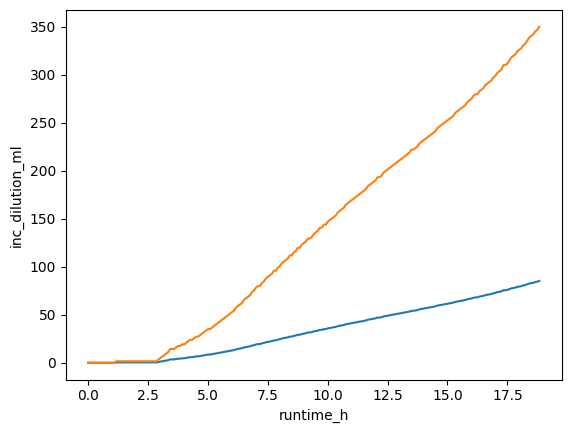

In [34]:
sns.lineplot(state, x='runtime_h', y='inc_dilution_ml')
sns.lineplot(state, x='runtime_h', y='inc_dilution_ml2')

Text(0, 0.5, 'Growth rate (volumes/hour)')

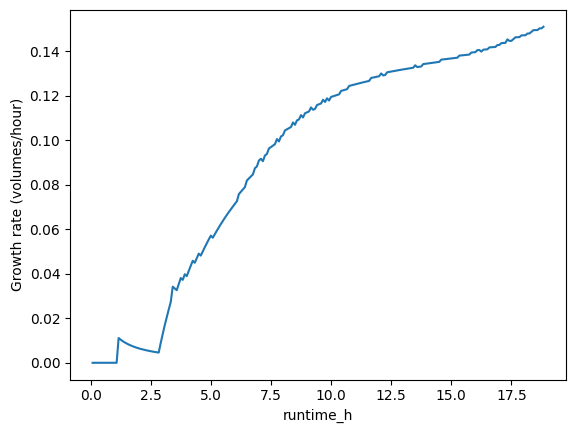

In [32]:
ax = sns.lineplot(state, x='runtime_h', y='growth_rate')
ax.set_ylabel('Growth rate (volumes/hour)')

Text(0, 0.5, 'Growth rate (volumes/hour)')

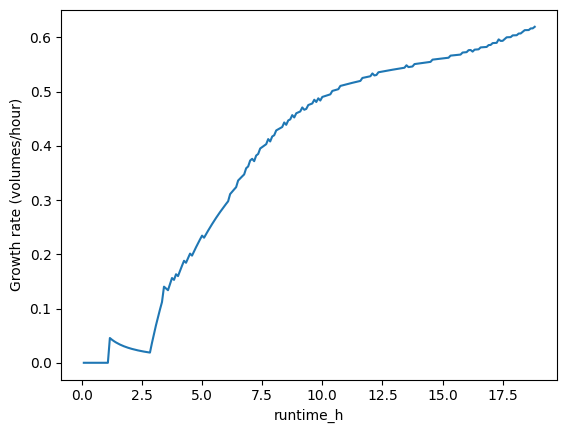

In [33]:
ax = sns.lineplot(state, x='runtime_h', y='growth_rate2')
ax.set_ylabel('Growth rate (volumes/hour)')

volume per burst = 1.5981735159817352 ml = 0.05327245053272451 inc. volumes


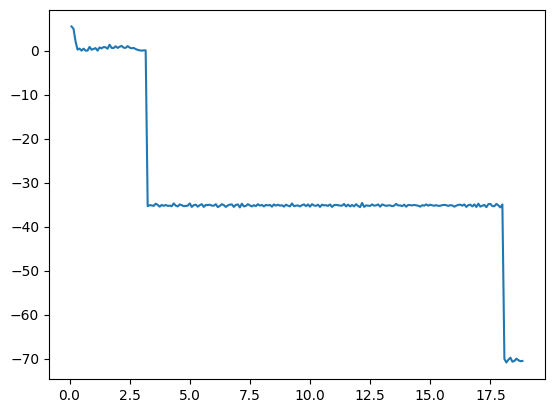

In [71]:
vol_per_burst_ml = TOTAL_VOL_ML / total_num_bursts
vol_per_burst_frac = vol_per_burst_ml / INC_VOL_ML
print(f'volume per burst = {vol_per_burst_ml} ml = {vol_per_burst_frac} inc. volumes')
#ts, gr = calculate_bact_growth2(state['inc_od'], state['inc_dilution'], vol_per_burst_frac, state['runtime_h'])
total_inc_bursts = state['inc_dilution'].values
od = state['inc_od'].values
burst_dilution = vol_per_burst_frac
runtime_hours = state['runtime_h'].values
inc_bursts_per_interval = total_inc_bursts[1:] - total_inc_bursts[:-1]

def rolling_window(a, window_size):
    # Calculate the number of elements to pad on each side
    pad_width = window_size // 2
    
    # Pad the array by duplicating the boundary elements
    padded_array = np.pad(a, pad_width, mode='edge')
    
    # Create a rolling window
    shape = (a.size, window_size)
    strides = (a.strides[0], a.strides[0])
    return np.lib.stride_tricks.as_strided(padded_array, shape=shape, strides=strides)


# Calculate median for each window
inc_bursts_per_interval_filtered = np.median(rolling_window(inc_bursts_per_interval, 25), axis=1)
inc_dil_per_interval = inc_bursts_per_interval_filtered * np.log(burst_dilution)
dt = runtime_hours[1:] - runtime_hours[:-1]
log_od = np.log(od)
log_od_diff = log_od[1:] - log_od[:-1]
growth_rate = (log_od_diff + inc_dil_per_interval) / dt
ts = runtime_hours[1:]
import matplotlib.pyplot as plt 
plt.plot(ts, growth_rate)

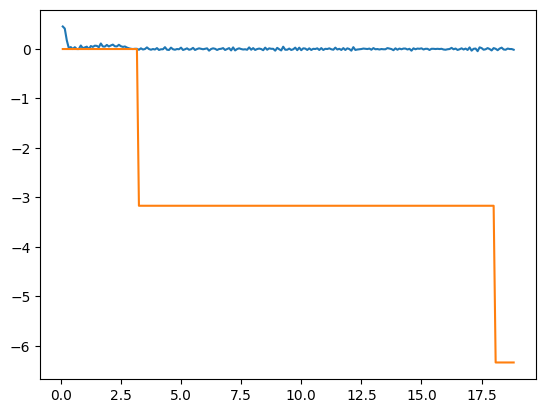

In [68]:
plt.plot(ts,log_od_diff)
plt.plot(ts,inc_dil_per_interval)

In [70]:
np.log(0.04205719778899303)

-3.168724735059427

<Axes: xlabel='runtime_h', ylabel='growth_rate'>

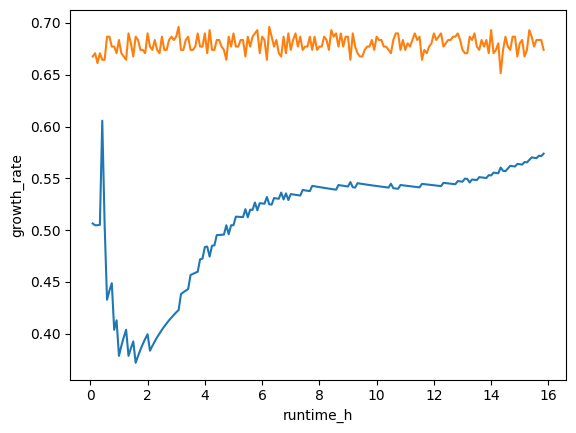

In [91]:
state_steady = state[state['runtime_h'] > 3].copy()
state_exp = state[state['runtime_h'] <= 3].copy()
state_steady['inc_dilution_ml2'] = state_steady['inc_dilution_ml2'] - state_exp['inc_dilution_ml2'].max()
state_steady['runtime_h'] = state_steady['runtime_h'] - state_exp['runtime_h'].max()
state_steady['growth_rate'] = state_steady.apply(lambda x: calculate_bact_growth_steady(x['inc_dilution_ml2'], x['runtime_h'], inc_vol=38), axis=1)
ax = sns.lineplot(state_steady, x='runtime_h', y='growth_rate')
sns.lineplot(state_steady, x='runtime_h', y='inc_od')


<Axes: xlabel='runtime_h', ylabel='growth_rate'>

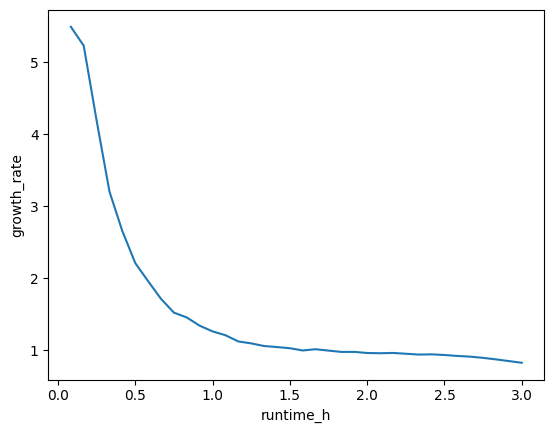

In [86]:
state_exp['growth_rate'] = calculate_bact_growth_exp(state_exp['inc_od'], state_exp['runtime_h'])
sns.lineplot(state_exp, x='runtime_h', y='growth_rate')